In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

In [3]:
data = {
    'Nama': ['Budi', 'Indra Wijaya', 'Angga Prawira', 'Teddy Dian', 'Rossa', 'Randi'],
    'Vocabulary': [90, 95, 60, 80, 70, 60],
    'Listening': [80, 90, 70, 90, 90, 70],
    'Grammar': [85, 80, 75, 80, 70, 70],
    'Writing': [70, 80, 80, 60, 65, None]
}

In [4]:
# Buat DataFrame
df = pd.DataFrame(data)
print("Data Mahasiswa:")
print(df)
print("\n")

Data Mahasiswa:
            Nama  Vocabulary  Listening  Grammar  Writing
0           Budi          90         80       85     70.0
1   Indra Wijaya          95         90       80     80.0
2  Angga Prawira          60         70       75     80.0
3     Teddy Dian          80         90       80     60.0
4          Rossa          70         90       70     65.0
5          Randi          60         70       70      NaN




In [ ]:
train_data = df.dropna()
predict_data = df[df['Writing'].isna()]

In [ ]:
X_train = train_data[['Vocabulary', 'Listening', 'Grammar']]
y_train = train_data['Writing']

In [ ]:
X_predict = predict_data[['Vocabulary', 'Listening', 'Grammar']]

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Model Regresi Linear:")
print(f"Intercept (a): {model.intercept_:.2f}")
print(f"Koefisien (b1, b2, b3): {model.coef_}")
print("\n")

Model Regresi Linear:
Intercept (a): 288.23
Koefisien (b1, b2, b3): [ 1.19948187 -1.61398964 -2.26165803]




In [ ]:
equation = f"Writing = {model.intercept_:.2f}"
for i, feature in enumerate(['Vocabulary', 'Listening', 'Grammar']):
    equation += f" + ({model.coef_[i]:.2f} × {feature})"
print(f"Persamaan Regresi: {equation}")

Persamaan Regresi: Writing = 288.23 + (1.20 × Vocabulary) + (-1.61 × Listening) + (-2.26 × Grammar)


In [ ]:
predicted_writing = model.predict(X_predict)
print(f"\nNilai Writing yang diprediksi untuk {predict_data['Nama'].values[0]}: {predicted_writing[0]:.2f}")


Nilai Writing yang diprediksi untuk Randi: 88.90


In [ ]:
df.loc[df['Writing'].isna(), 'Writing'] = predicted_writing[0]
print("\nData Mahasiswa Setelah Prediksi:")
print(df)


Data Mahasiswa Setelah Prediksi:
            Nama  Vocabulary  Listening  Grammar    Writing
0           Budi          90         80       85  70.000000
1   Indra Wijaya          95         90       80  80.000000
2  Angga Prawira          60         70       75  80.000000
3     Teddy Dian          80         90       80  60.000000
4          Rossa          70         90       70  65.000000
5          Randi          60         70       70  88.898964


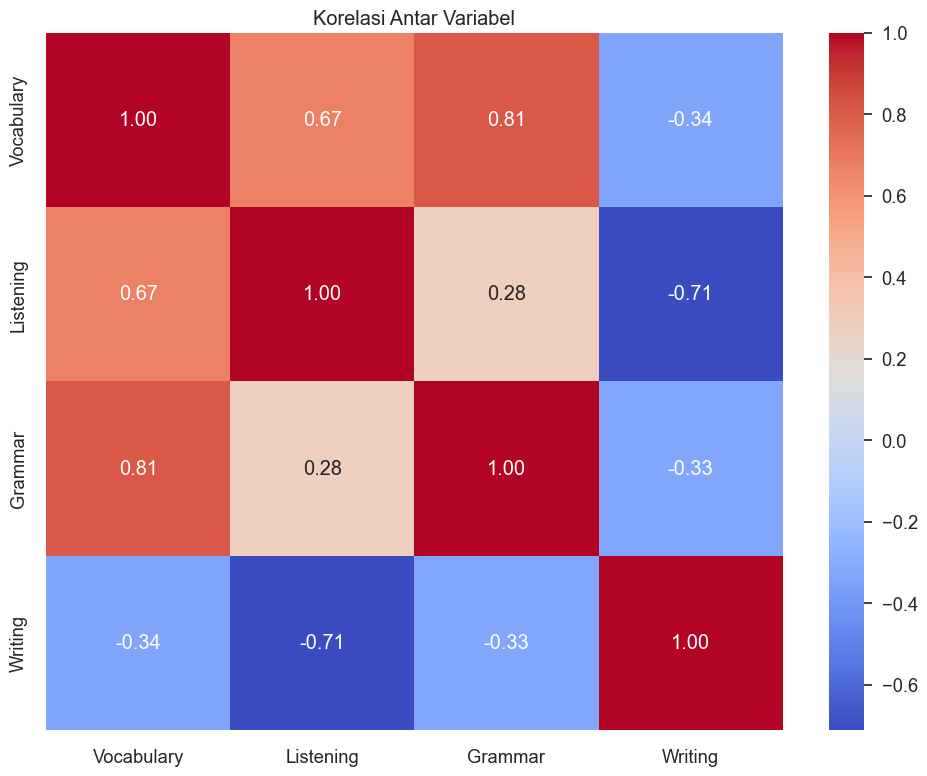

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('Nama', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

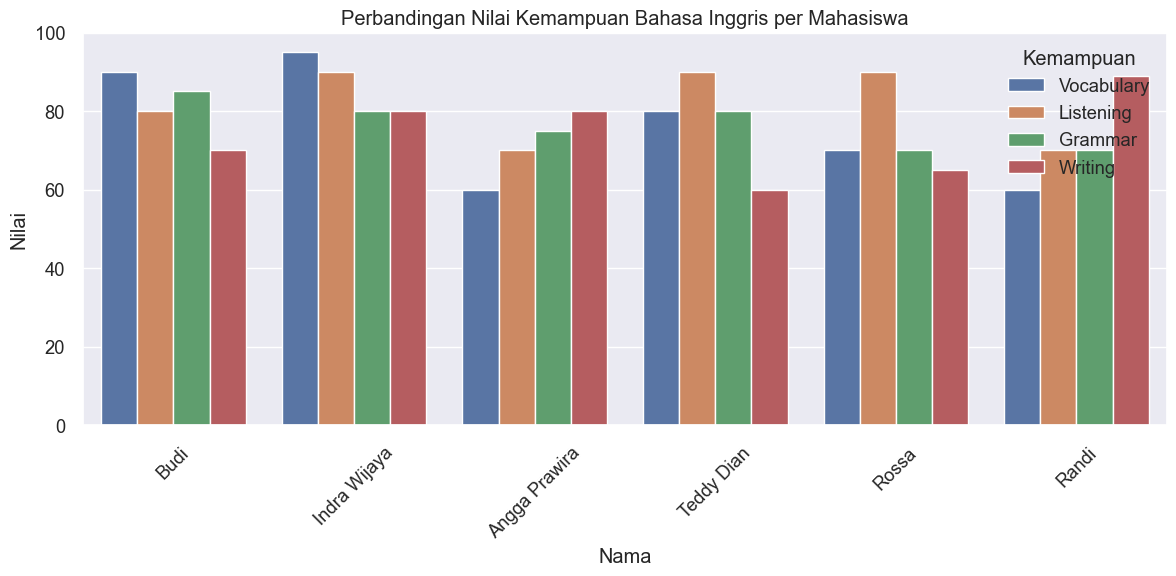

In [ ]:
plt.figure(figsize=(12, 6))
df_melted = pd.melt(df, id_vars=['Nama'], value_vars=['Vocabulary', 'Listening', 'Grammar', 'Writing'],
                    var_name='Kemampuan', value_name='Nilai')
sns.barplot(x='Nama', y='Nilai', hue='Kemampuan', data=df_melted)
plt.title('Perbandingan Nilai Kemampuan Bahasa Inggris per Mahasiswa')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.legend(title='Kemampuan')
plt.tight_layout()
plt.show()

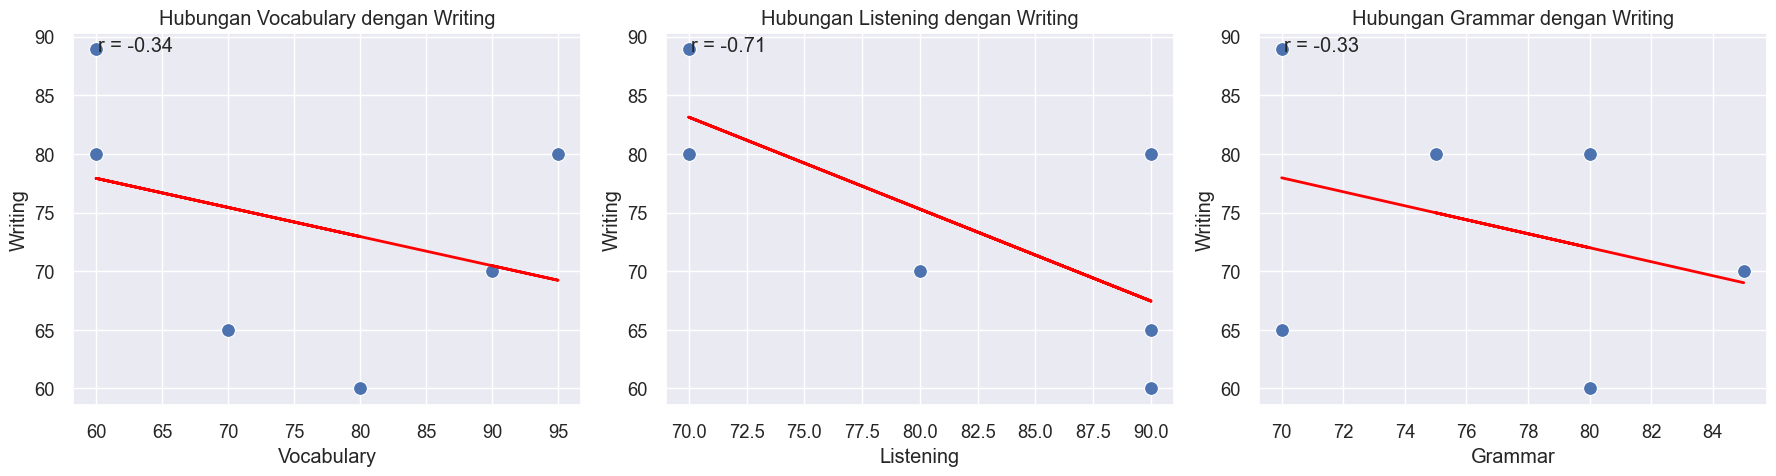

In [15]:
# Scatter plot untuk melihat hubungan antara setiap variabel independen dengan Writing
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
skills = ['Vocabulary', 'Listening', 'Grammar']

for i, skill in enumerate(skills):
    sns.scatterplot(x=skill, y='Writing', data=df, ax=axes[i], s=100)
    axes[i].set_title(f'Hubungan {skill} dengan Writing')
    
    # Tambahkan garis tren
    x = df[skill].values.reshape(-1, 1)
    y = df['Writing'].values
    reg = LinearRegression().fit(x, y)
    axes[i].plot(x, reg.predict(x), color='red', linewidth=2)
    
    # Tambahkan koefisien korelasi
    corr = df[[skill, 'Writing']].corr().iloc[0, 1]
    axes[i].annotate(f'r = {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')

plt.tight_layout()
plt.show()

In [16]:
# Evaluasi model pada data training
y_pred_train = model.predict(X_train)
train_score = model.score(X_train, y_train)
print(f"\nR² Score pada data training: {train_score:.4f}")


R² Score pada data training: 0.8055


In [17]:
# Menghitung Mean Squared Error (MSE) pada data training
mse = np.mean((y_train - y_pred_train)**2)
print(f"Mean Squared Error (MSE) pada data training: {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) pada data training: {np.sqrt(mse):.4f}")

Mean Squared Error (MSE) pada data training: 12.4482
Root Mean Squared Error (RMSE) pada data training: 3.5282


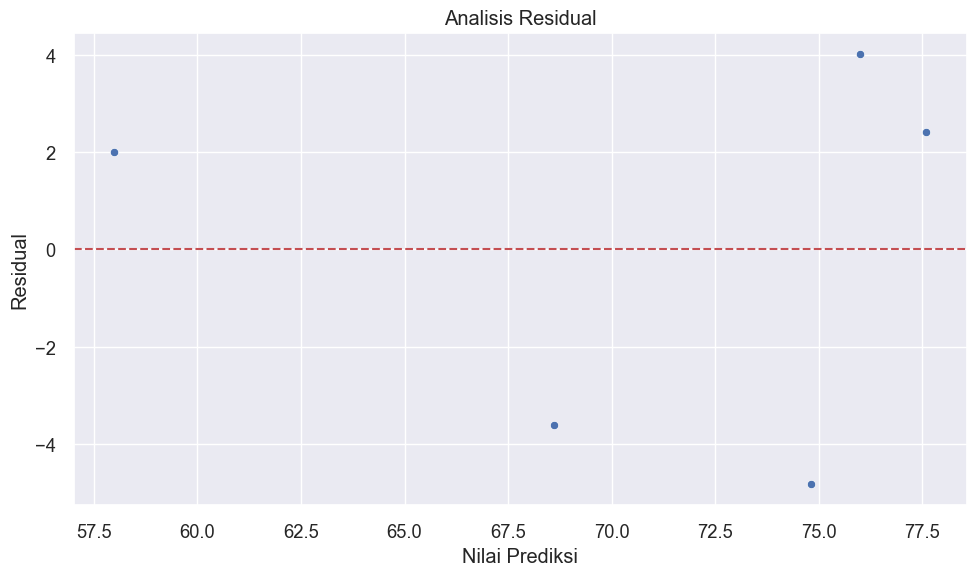

In [18]:
# Analisis residual
residuals = y_train - y_pred_train

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_train, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residual')
plt.title('Analisis Residual')
plt.tight_layout()
plt.show()